# 02 - Feature Engineering

**Goal:** Merge energy and weather datasets, engineer features, and save a modelling-ready dataset.

## 1. Setup

In [25]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from features import create_features

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

## 2. Load Raw Data

In [26]:
energy = pd.read_csv('../data/energy_dataset.csv')
weather = pd.read_csv('../data/weather_features.csv')

energy['time'] = pd.to_datetime(energy['time'], utc=True).dt.tz_localize(None)
weather['dt_iso'] = pd.to_datetime(weather['dt_iso'], utc=True).dt.tz_localize(None)

print('Energy shape:', energy.shape)
print('Weather shape:', weather.shape)

Energy shape: (35064, 29)
Weather shape: (178396, 17)


## 3. Clean Energy Data

In [27]:
# Check target
print('Missing total load actual:', energy['total load actual'].isna().sum())
print('Date range:', energy['time'].min(), '→', energy['time'].max())

energy = energy.dropna(subset=['total load actual']).reset_index(drop=True)

energy = energy.sort_values('time').reset_index(drop=True)
energy = energy.ffill(limit=3)

print('Energy shape after cleaning:', energy.shape)

Missing total load actual: 36
Date range: 2014-12-31 23:00:00 → 2018-12-31 22:00:00
Energy shape after cleaning: (35028, 29)


## 4. Aggregate Weather Across Cities

The weather data has one row per city per hour (5 cities: Valencia, Madrid, Bilbao, Barcelona, Seville).
Since our energy data is national, we aggregate weather to a single hourly summary.

In [28]:
weather_num_cols = ['temp', 'temp_min', 'temp_max', 'pressure', 'humidity',
                    'wind_speed', 'wind_deg', 'rain_1h', 'rain_3h', 'snow_3h', 'clouds_all']

weather_agg = (
    weather
    .groupby('dt_iso')[weather_num_cols]
    .agg(['mean', 'min', 'max'])
)

weather_agg.columns = ['_'.join(col).strip() for col in weather_agg.columns]
weather_agg = weather_agg.reset_index().rename(columns={'dt_iso': 'time'})

print('Aggregated weather shape:', weather_agg.shape)
weather_agg.head(3)

Aggregated weather shape: (35064, 34)


,time,temp_mean,temp_min,temp_max,temp_min_mean,temp_min_min,temp_min_max,temp_max_mean,temp_max_min,temp_max_max,...,rain_1h_max,rain_3h_mean,rain_3h_min,rain_3h_max,snow_3h_mean,snow_3h_min,snow_3h_max,clouds_all_mean,clouds_all_min,clouds_all_max
0,2014-12-31 23:00:00,272.491463,267.325,281.625,272.491463,267.325,281.625,272.491463,267.325,281.625,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
1,2015-01-01 00:00:00,272.512700,267.325,281.625,272.512700,267.325,281.625,272.512700,267.325,281.625,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
2,2015-01-01 01:00:00,272.099137,266.186,281.286,272.099137,266.186,281.286,272.099137,266.186,281.286,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0


The weather data has one row per city per hour across 5 cities, so it's about 5x larger than the energy data. Since energy consumption is reported at the national level, I aggregated weather across cities, took the mean, min, and max for each numeric column per hour. This collapses it down to ~35,000 rows that merge cleanly with the energy data on time.  

Temperature doesn't vary much between cities (the spread between warmest and coldest city is usually only a few degrees), so averaging is fine there. Wind and rain probably differ more between coastal and inland cities, but for a first pass the aggregation keeps things simple. A more granular approach would be to keep city-level weather features for high-variance variables like wind and rain, rather than averaging them.

## 5. Merge Energy + Weather

In [29]:
df = pd.merge(energy, weather_agg, on='time', how='left')

print('Merged shape:', df.shape)
print('Weather NaNs after merge:', df[weather_agg.columns[1:]].isna().sum().sum())

Merged shape: (35028, 62)
Weather NaNs after merge: 0


## 6. Apply Feature Engineering from src/features.py

In [30]:
# Use the create_features function which applies time, lag, and rolling features
TARGET = 'total load actual'
df = create_features(df, target_col=TARGET, time_col='time')

feature_cols = [c for c in df.columns if any(
    c.startswith(p) for p in ['hour', 'dayofweek', 'month', 'quarter', 'year',
                               'is_weekend', 'day_of_year',
                               f'{TARGET}_lag_', f'{TARGET}_rolling_']
)]
print(f'Engineered {len(feature_cols)} features:')
for c in sorted(feature_cols):
    print(f'  {c}')

Engineered 21 features:
  day_of_year
  dayofweek
  hour
  is_weekend
  month
  quarter
  total load actual_lag_1
  total load actual_lag_168
  total load actual_lag_2
  total load actual_lag_24
  total load actual_lag_3
  total load actual_lag_48
  total load actual_rolling_mean_12
  total load actual_rolling_mean_168
  total load actual_rolling_mean_24
  total load actual_rolling_mean_6
  total load actual_rolling_std_12
  total load actual_rolling_std_168
  total load actual_rolling_std_24
  total load actual_rolling_std_6
  year


## 7. Additional Holiday Features

In [31]:
spanish_holidays = pd.to_datetime([
    # 2015
    '2015-01-01', '2015-01-06', '2015-04-03', '2015-05-01', '2015-08-15',
    '2015-10-12', '2015-11-01', '2015-12-06', '2015-12-08', '2015-12-25',
    # 2016
    '2016-01-01', '2016-01-06', '2016-03-25', '2016-05-01', '2016-08-15',
    '2016-10-12', '2016-11-01', '2016-12-06', '2016-12-08', '2016-12-25',
    # 2017
    '2017-01-01', '2017-01-06', '2017-04-14', '2017-05-01', '2017-08-15',
    '2017-10-12', '2017-11-01', '2017-12-06', '2017-12-08', '2017-12-25',
    # 2018
    '2018-01-01', '2018-01-06', '2018-03-30', '2018-05-01', '2018-08-15',
    '2018-10-12', '2018-11-01', '2018-12-06', '2018-12-08', '2018-12-25',
])

df['is_holiday'] = df['time'].dt.normalize().isin(spanish_holidays).astype(int)
df['is_holiday_or_weekend'] = ((df['is_weekend'] == 1) | (df['is_holiday'] == 1)).astype(int)

print(f'Holiday rows: {df["is_holiday"].sum()}')
print(f'Holiday or weekend rows: {df["is_holiday_or_weekend"].sum()}')

Holiday rows: 960
Holiday or weekend rows: 10786


### Add Lagged Price as a Feature

In [32]:
df['price_day_ahead_lag_24'] = df['price day ahead'].shift(24)

## 8. Additional Weather-Derived Features

In [33]:
# Temperature in Kelvin - comfort baseline ~18°C = 291.15K
COMFORT_K = 291.15

# Heating/cooling demand proxies
df['heating_need'] = np.maximum(COMFORT_K - df['temp_mean'], 0)
df['cooling_need'] = np.maximum(df['temp_mean'] - COMFORT_K, 0)

# Temperature range (weather volatility)
df['temp_range'] = df['temp_max_max'] - df['temp_min_min']

# Wind chill interaction
df['wind_chill_proxy'] = df['wind_speed_mean'] * df['heating_need']

print('Added 4 weather-derived features.')

Added 4 weather-derived features.


## 9. Drop Warm-Up Rows

In [34]:
# Lag and rolling features create NaNs for the first 168 hours (7 days)
lag_roll_cols = [c for c in df.columns if f'{TARGET}_lag_' in c or f'{TARGET}_rolling_' in c]
rows_before = len(df)
df_clean = df.dropna(subset=lag_roll_cols).reset_index(drop=True)
print(f'Dropped {rows_before - len(df_clean)} warm-up rows')
print(f'Clean dataset: {df_clean.shape}')

Dropped 168 warm-up rows
Clean dataset: (34860, 90)


## 10. Feature Correlation with Target

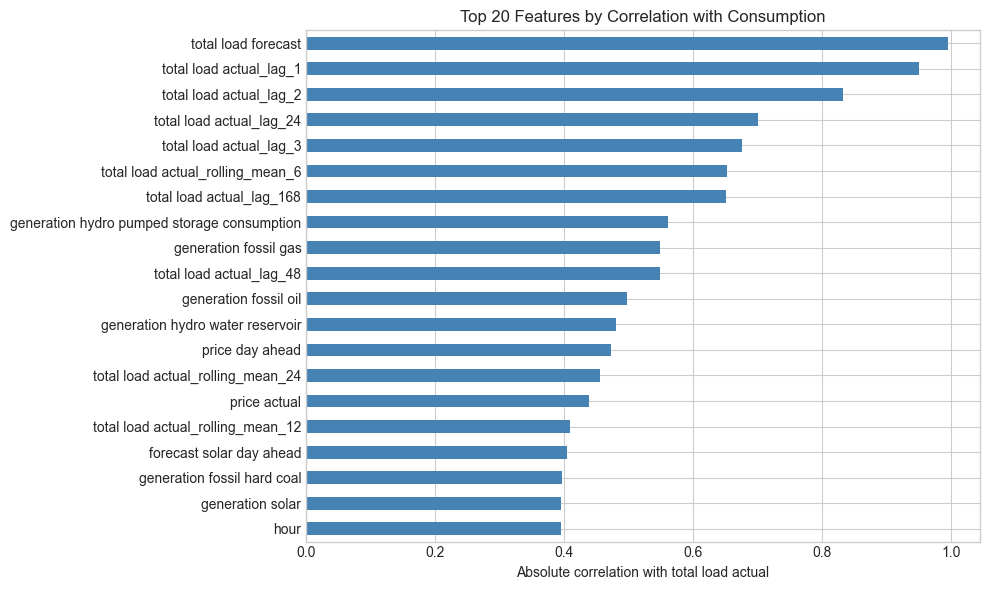

In [35]:
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != TARGET]

corr = df_clean[numeric_cols + [TARGET]].corr()[TARGET].drop(TARGET)
top_corr = corr.abs().sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
top_corr.plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('Absolute correlation with total load actual')
ax.set_title('Top 20 Features by Correlation with Consumption')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Lag features dominate, the strongest predictors after the TSO's own forecast are recent consumption values (lag 1h, 2h, 24h). Rolling means also rank high, capturing the recent trend. Generation and price columns show moderate correlation (~0.4-0.6) but these aren't used as features since they're effects of demand, not causes. Weather features and the engineered heating/cooling proxies don't appear in the top 20 here. It's likely because linear correlation doesn't capture non-linear relationships well.

## 11. Save Modelling-Ready Dataset

In [36]:
output_path = '../data/features_dataset.csv'
df_clean.to_csv(output_path, index=False)
print(f'Saved to {output_path} — {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns')

Saved to ../data/features_dataset.csv — 34,860 rows × 90 columns
